# API Data Wrangling with Open-Meteo

In this exercise, we will:

- Fetch historical weather data using the **Open-Meteo API**.
- Parse and clean the data using **pandas**.
- Perform exploratory data analysis.
- Visualize weather trends.

In [1]:
# Install required packages if not already installed
# !pip install requests pandas matplotlib --quiet

In [2]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Configure matplotlib for inline display in Jupyter
%matplotlib inline

## Understand the Open-Meteo API

- **API Endpoint**: `https://archive-api.open-meteo.com/v1/archive`
- **Parameters**:
  - `latitude`: Latitude of the location.
  - `longitude`: Longitude of the location.
  - `start_date`: Start date of the data (YYYY-MM-DD).
  - `end_date`: End date of the data (YYYY-MM-DD).
  - `hourly`: Comma-separated list of variables (e.g., temperature, precipitation).
  - `timezone`: Timezone of the data.

**Documentation**: [Open-Meteo API Docs](https://open-meteo.com/en/docs)

In [3]:
# Step 1: Set Up Parameters

# Location coordinates for New York City
latitude = 40.7128
longitude = -74.0060

# Date range
start_date = '2023-01-01'
end_date = '2023-01-07'  # One week of data

# Variables to fetch
hourly_variables = ['temperature_2m', 'relativehumidity_2m', 'precipitation']


In [4]:
# Step 2: Make the API Request

base_url = 'https://archive-api.open-meteo.com/v1/archive'

params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/New_York'
}

response = requests.get(base_url, params=params)


In [5]:
# Check if the request was successful

if response.status_code == 200:
    print('Data fetched successfully!')
else:
    print(f'Failed to fetch data. Status code: {response.status_code}')


Data fetched successfully!


In [6]:
# Step 3: Load Data into pandas DataFrame

data = response.json()
hourly_data = data['hourly']

df = pd.DataFrame(hourly_data)
df.head()


,time,temperature_2m,relativehumidity_2m,precipitation
0,2023-01-01T00:00,10.9,99,1.0
1,2023-01-01T01:00,10.6,99,1.0
2,2023-01-01T02:00,10.6,98,0.1
3,2023-01-01T03:00,10.4,96,0.0
4,2023-01-01T04:00,9.8,95,0.0


In [7]:
# Step 4: Data Cleaning

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Set 'time' as the index
df.set_index('time', inplace=True)

# Check for missing values
df.isnull().sum()


temperature_2m         0
relativehumidity_2m    0
precipitation          0
dtype: int64

In [8]:
# Handle missing values (if any)
df.ffill(inplace=True)  # Forward fill


In [9]:
# Step 5: Exploratory Data Analysis

# Summary Statistics
df.describe()

,temperature_2m,relativehumidity_2m,precipitation
count,168.000000,168.000000,168.000000
mean,8.501190,86.422619,0.142857
std,3.494598,12.799933,0.436037
min,0.500000,45.000000,0.000000
25%,6.100000,81.000000,0.000000
50%,8.400000,90.500000,0.000000
75%,11.200000,97.000000,0.000000
max,18.000000,100.000000,3.100000


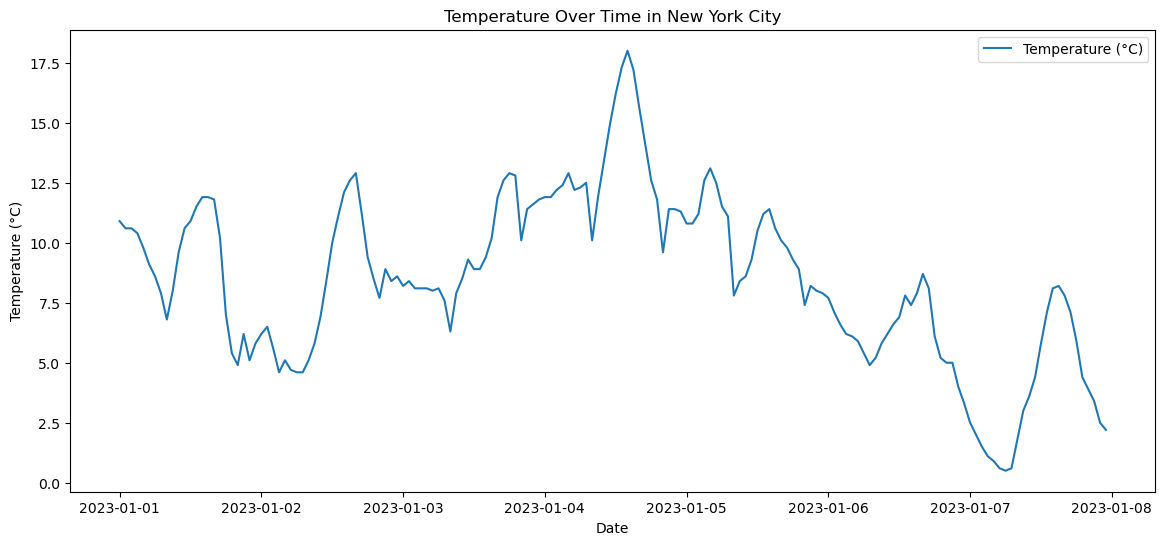

In [10]:
# Plot Temperature Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['temperature_2m'], label='Temperature (°C)')
plt.title('Temperature Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

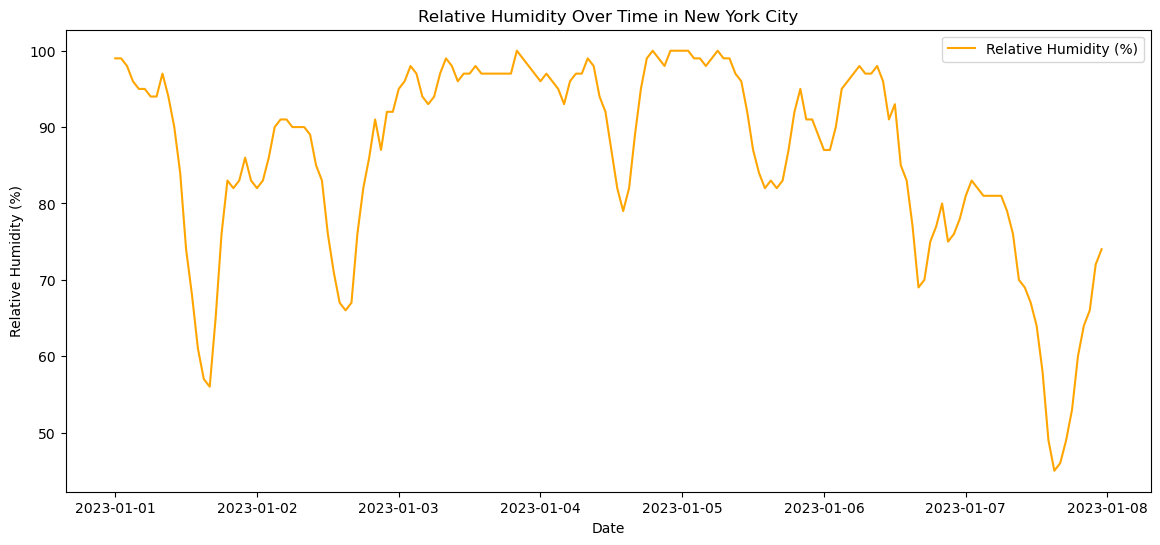

In [11]:
# Plot Relative Humidity Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['relativehumidity_2m'], color='orange', label='Relative Humidity (%)')
plt.title('Relative Humidity Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.legend()
plt.show()


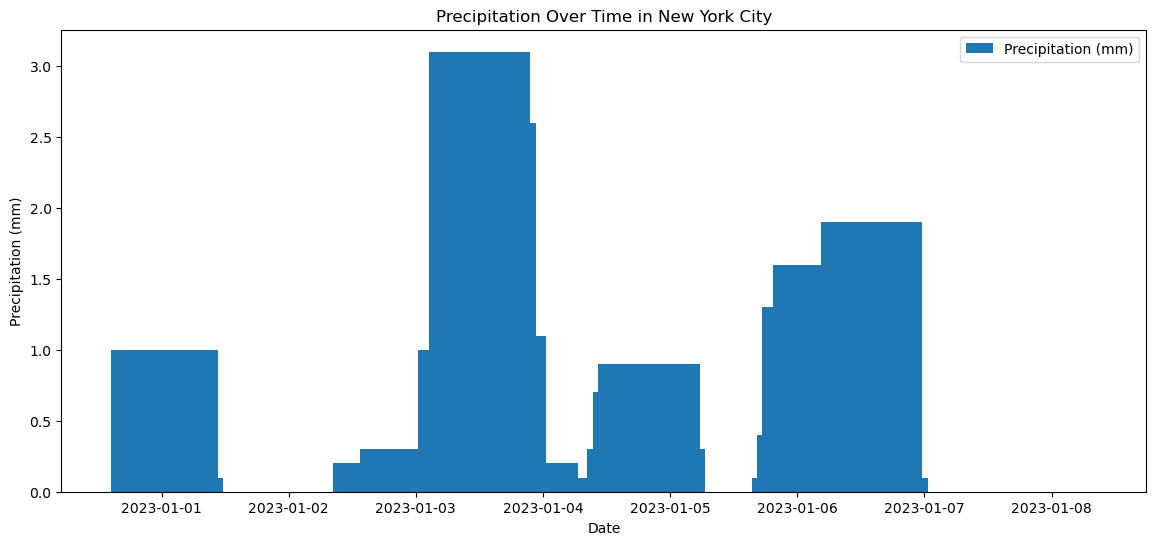

In [12]:
# Plot Precipitation Over Time

plt.figure(figsize=(14, 6))
plt.bar(df.index, df['precipitation'], label='Precipitation (mm)')
plt.title('Precipitation Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.show()


In [13]:
# Step 6: Correlation Analysis

# Calculate correlation between temperature and humidity
correlation = df['temperature_2m'].corr(df['relativehumidity_2m'])
print(f'Correlation between Temperature and Relative Humidity: {correlation:.2f}')


Correlation between Temperature and Relative Humidity: 0.24


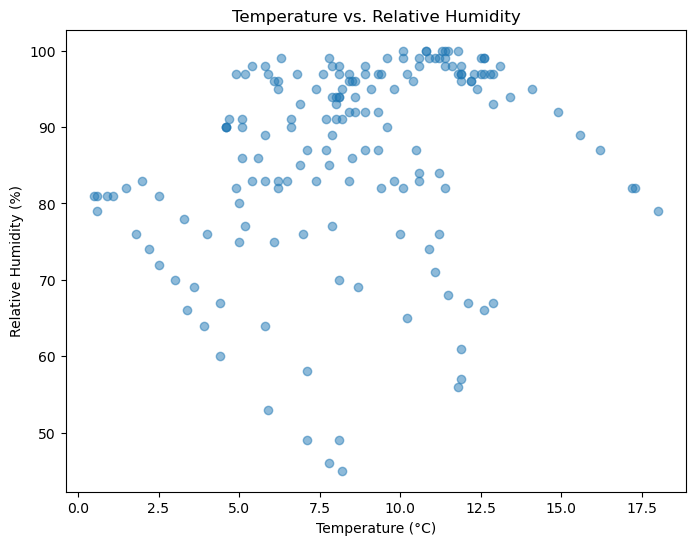

In [14]:
# Scatter Plot of Temperature vs. Relative Humidity

plt.figure(figsize=(8, 6))
plt.scatter(df['temperature_2m'], df['relativehumidity_2m'], alpha=0.5)
plt.title('Temperature vs. Relative Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


In [15]:
# Step 7: Resample Data to Daily Averages

daily_avg = df.resample('D').mean()
daily_avg.head()


,temperature_2m,relativehumidity_2m,precipitation
time,,,
2023-01-01,8.979167,83.708333,0.087500
2023-01-02,7.895833,83.458333,0.020833
2023-01-03,9.545833,96.875000,0.395833
2023-01-04,13.129167,94.166667,0.095833
2023-01-05,10.041667,92.666667,0.000000


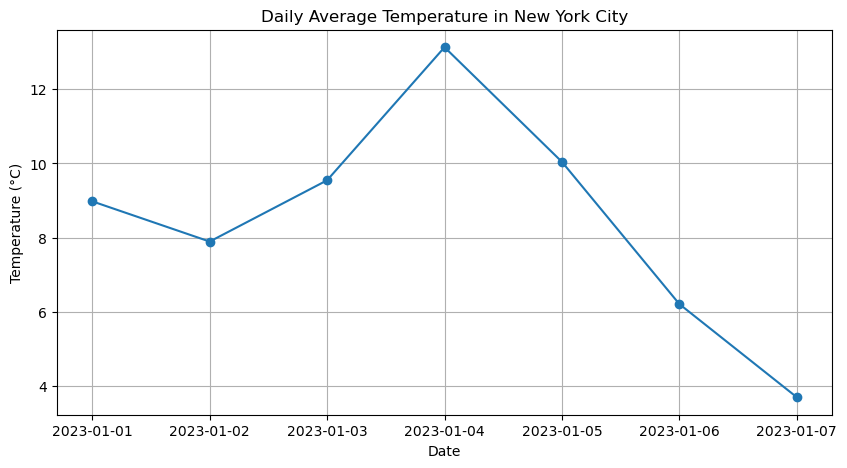

In [16]:
# Plot Daily Average Temperature

plt.figure(figsize=(10, 5))
plt.plot(daily_avg.index, daily_avg['temperature_2m'], marker='o')
plt.title('Daily Average Temperature in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


In [17]:
# Step 8: Compare with Another Location (Los Angeles)

# Coordinates for Los Angeles
latitude_la = 34.0522
longitude_la = -118.2437

params_la = {
    'latitude': latitude_la,
    'longitude': longitude_la,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}

response_la = requests.get(base_url, params=params_la)

# Load and clean Los Angeles data
data_la = response_la.json()
hourly_data_la = data_la['hourly']
df_la = pd.DataFrame(hourly_data_la)

df_la['time'] = pd.to_datetime(df_la['time'])
df_la.set_index('time', inplace=True)
df_la.ffill(inplace=True)


In [18]:
# Resample Los Angeles Data to Daily Averages

daily_avg_la = df_la.resample('D').mean()


In [19]:
# Combine DataFrames for Comparison

combined_temp = pd.DataFrame({
    'New York': daily_avg['temperature_2m'],
    'Los Angeles': daily_avg_la['temperature_2m']
})


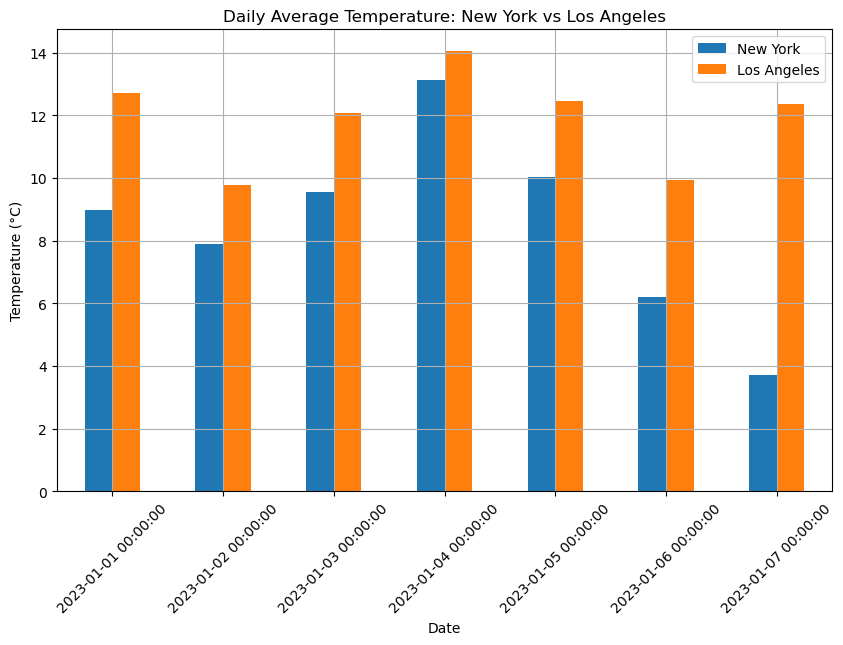

In [20]:
# Plot Comparison of Daily Average Temperature

combined_temp.plot(kind='bar', figsize=(10, 6))
plt.title('Daily Average Temperature: New York vs Los Angeles')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [21]:
# Step 9: Advanced Analysis - Temperature Difference

# Calculate Temperature Difference
combined_temp['Temp Difference'] = combined_temp['Los Angeles'] - combined_temp['New York']
combined_temp


,New York,Los Angeles,Temp Difference
time,,,
2023-01-01,8.979167,12.704167,3.725000
2023-01-02,7.895833,9.762500,1.866667
2023-01-03,9.545833,12.079167,2.533333
2023-01-04,13.129167,14.037500,0.908333
2023-01-05,10.041667,12.454167,2.412500
2023-01-06,6.212500,9.929167,3.716667
2023-01-07,3.704167,12.366667,8.662500


In [22]:
# Step 10: Save Data to CSV (Optional)

# Save New York data
df.to_csv('new_york_weather.csv')

# Save Los Angeles data
df_la.to_csv('los_angeles_weather.csv')


## Conclusion

In this exercise, we:

- Accessed and retrieved data from the **Open-Meteo API**.
- Cleaned and preprocessed JSON data using **pandas**.
- Performed exploratory data analysis and visualization.
- Compared weather patterns between **New York City** and **Los Angeles**.

---

**Next Steps**:

- **Extend the Date Range**: Analyze seasonal trends by fetching data over several months.
- **Fetch Additional Variables**: Include wind speed, atmospheric pressure, or other interesting variables.
- **Forecasting**: Use statistical methods or machine learning models to forecast future weather patterns.
- **Global Analysis**: Compare data from other global cities to gain broader insights.


## Exercises for Students

Now it's your turn! Below are some exercises to reinforce what you've learned. Try to complete them without looking at the solutions.

### Exercise: Compare Rainfall Between London and Seattle

- **Objective**: Compare the total weekly rainfall between London and Seattle over a full year.
- **Tasks**:
  1. **Fetch Data**: Retrieve hourly precipitation data for London and Seattle for the year 2022.
     - **London Coordinates**: Latitude `51.5074`, Longitude `-0.1278`
     - **Seattle Coordinates**: Latitude `47.6062`, Longitude `-122.3321`
  2. **Data Cleaning**: Convert the time columns to datetime objects and set them as the index. Handle any missing values.
  3. **Resample Data**: Resample the hourly data to weekly totals.
  4. **Visualization**: Plot the weekly total precipitation for both cities on the same graph.
  5. **Analysis**: Determine which city had more rainfall overall and identify any interesting patterns.

**Note**: Remember to handle any API limitations, such as data availability or rate limits, and to be mindful of the size of the data you're requesting.

### Tips:

- **API Parameters**: Make sure to adjust the parameters like `latitude`, `longitude`, `start_date`, `end_date`, `hourly`, and `timezone` as needed.
- **Error Handling**: Always check if your API requests are successful before proceeding.
- **Data Storage**: Consider saving your DataFrames to CSV files for future analysis.
- **Visualization**: Customize your plots with titles, labels, legends, and gridlines for better readability.

Happy coding!


In [23]:
# Set Up Parameters

# London Lat and Long Coordinates
latitude_london = 51.5074
longitude_london = -0.1278

# Seattle Lat and Long Coordinates
latitude_seattle = 47.6062
longitude_seattle = -122.3321

# Date range for analysis
start_date = '2022-01-01'
end_date = '2022-12-31'

# Variables
hourly_variables = ['precipitation']

In [24]:
base_url = 'https://archive-api.open-meteo.com/v1/archive'

# London parameters
params_london = {
    'latitude': latitude_london,
    'longitude': longitude_london,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'Europe/London'
}

# Seattle parameters
params_seattle = {
    'latitude': latitude_seattle,
    'longitude': longitude_seattle,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}

# API requests
response_london = requests.get(base_url, params=params_london)
response_seattle = requests.get(base_url, params=params_seattle)

In [25]:
# Error checking - were the requests successful

if response_london.status_code == 200:
    print('London Data fetched successfully!')
else:
    print(f'Failed to fetch London data. Status code: {response_london.status_code}')

if response_seattle.status_code == 200:
    print('Seattle Data fetched successfully!')
else:
    print(f'Failed to fetch Seattle data. Status code: {response_seattle.status_code}')

London Data fetched successfully!
Seattle Data fetched successfully!


In [26]:
# Load data into pandas DataFrames

# London dataframe load
data_london = response_london.json()
hourly_data_london = data_london['hourly']
df_london = pd.DataFrame(hourly_data_london)

# Seattle dataframe load
data_seattle = response_seattle.json()
hourly_data_seattle = data_seattle['hourly']
df_seattle = pd.DataFrame(hourly_data_seattle)

In [27]:
# Clean data

# Convert 'time' columns to datetime usable
df_london['time'] = pd.to_datetime(df_london['time'])
df_seattle['time'] = pd.to_datetime(df_seattle['time'])

# Set 'time' as the index value
df_london.set_index('time', inplace=True)
df_seattle.set_index('time', inplace=True)

# Check for missing values before fill
print("London missing values before fill:")
print(df_london.isnull().sum())

print("\nSeattle missing values before fill:")
print(df_seattle.isnull().sum())

# Handle missing values, if any
df_london.ffill(inplace=True)
df_seattle.ffill(inplace=True)

# Check for missing values after fill
print("\nLondon missing values after fill:")
print(df_london.isnull().sum())

print("\nSeattle missing values after fill:")
print(df_seattle.isnull().sum())

London missing values before fill:
precipitation    0
dtype: int64

Seattle missing values before fill:
precipitation    0
dtype: int64

London missing values after fill:
precipitation    0
dtype: int64

Seattle missing values after fill:
precipitation    0
dtype: int64


In [28]:
weekly_london = df_london['precipitation'].resample('W').sum() 
weekly_seattle = df_seattle['precipitation'].resample('W').sum()

In [29]:
# Resample hourly precipitation data to weekly totals values

weekly_london = df_london['precipitation'].resample('W').sum()
weekly_seattle = df_seattle['precipitation'].resample('W').sum()

# Total annual precipitation by London and Seattle, based on weekly totals
total_london = weekly_london.sum()
total_seattle = weekly_seattle.sum()

print(f"Total London precipitation in 2022: {total_london:.2f} mm")
print(f"Total Seattle precipitation in 2022: {total_seattle:.2f} mm")

Total London precipitation in 2022: 662.80 mm
Total Seattle precipitation in 2022: 1131.20 mm


In [30]:
print("London API metadata:")
print(data_london['latitude'], data_london['longitude'], data_london['timezone'])

print("\nSeattle API metadata:")
print(data_seattle['latitude'], data_seattle['longitude'], data_seattle['timezone'])

London API metadata:
51.493847 -0.1630249 Europe/London

Seattle API metadata:
47.627415 -122.32291 America/Los_Angeles


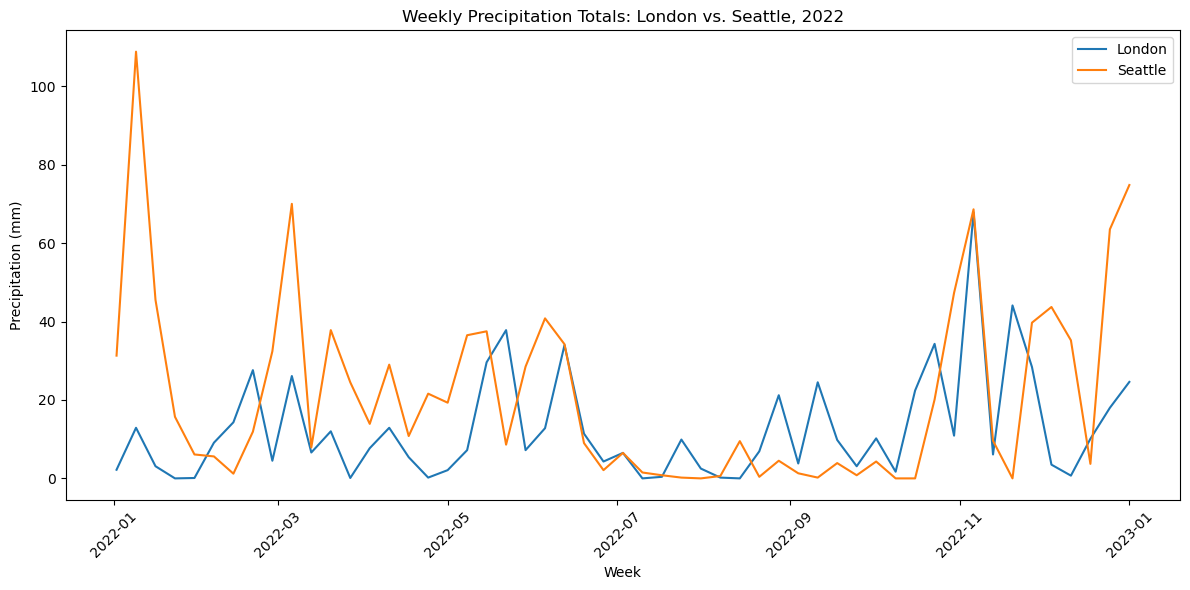

In [31]:
# Plot the London and Seattle data

plt.figure(figsize=(12, 6))

plt.plot(weekly_london.index, weekly_london, label='London')
plt.plot(weekly_seattle.index, weekly_seattle, label='Seattle')

plt.title('Weekly Precipitation Totals: London vs. Seattle, 2022')
plt.xlabel('Week')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
"""
Seattle Vs. London Rain Analysis for 2022
Seattle had more rainfall than London for the first and second quarters of 2022.  This trend reversed itself in the third quarter, with the fourth quarter slightly reversing again in favor of Seattle.  Other observations about the weekly rain totals for the two cities include large spikes in Seattle’s measured precipitation, with London experiencing fewer deviations from its mean value.  We also note that during the third quarter the volatility in Seattle’s rainfall was close to flat.  There were few instances where the rainfall of the two cities moved in tandem, though for late October and early November some positive correlation is measurable. 
"""

